<a href="https://cognitiveclass.ai"><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DL0101EN-SkillsNetwork/images/IDSN-logo.png" width="400"> </a>

# Keras ile Sınıflandırma Modelleri

Tahmini süre: **30** dakika

## Introduction


Bu laboratuvar çalışmasında, sınıflandırma problemleri için modeller oluşturmak üzere Keras kütüphanesini nasıl kullanacağımızı öğreneceğiz. Bu sefer, popüler MNIST veri setini, yani bir görüntü veri setini kullanacağız.

<strong>MNIST veri seti</strong>, yani Değiştirilmiş Ulusal Standartlar ve Teknoloji Enstitüsü veri seti, çeşitli görüntü işleme sistemlerini eğitmek için yaygın olarak kullanılan büyük bir el yazısı rakam veri setidir. Veri seti ayrıca makine öğrenimi alanında eğitim ve test için de yaygın olarak kullanılmaktadır.

MNIST veri seti, lise öğrencileri ve Amerika Birleşik Devletleri Nüfus Sayım Bürosu çalışanları tarafından yazılan rakamların 60.000 eğitim görüntüsü ve 10.000 test görüntüsünü içermektedir.

Ayrıca, bu şekilde, geleneksel sinir ağlarının, bir sonraki modülde oluşturacağımız evrişimsel sinir ağlarıyla nasıl karşılaştırıldığını da göreceksiniz.

## Bu Not Defterinin Amaçları
* Çeşitli görüntü işleme sistemlerini eğitmek için MNIST veritabanını kullanmak
* Bir sinir ağı oluşturmak
* Ağı eğitmek ve test etmek

## İçindekiler

<div class="alert alert-block alert-info" style="margin-top: 20px">

<font size = 3>

1. <a href="#Import-Keras-and-Packages">Keras ve Paketleri İçe Aktar</a>
2. <a href="#Build-a-Neural-Network">Sinir Ağı Oluştur</a>
3. <a href="#Train-and-Test-the-Network">Ağı Eğit ve Test Et</a>

</font>
</div>

Öncelikle Keras'ı ve diğer gerekli kütüphaneleri kurarak başlayalım.

Aşağıdaki gerekli kütüphaneler Skills Network Labs ortamında önceden yüklü değildir. Bunları yüklemek için aşağıdaki hücreyi çalıştırmanız gerekecektir:

In [1]:
!pip install tensorflow_cpu==2.18.0
!pip install matplotlib==3.9.2

print("==== All required libraries are installed =====")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 99.3 MB/s eta 0:00:00
==== All required libraries are installed =====


#### TensorFlow uyarı mesajlarını bastırma
TensorFlow için CPU mimarisi kullanımından kaynaklanan uyarı mesajlarını bastırmak için aşağıdaki kodu kullanıyoruz.

GPU mimarisi kullanıyorsanız bu satırları **yorum satırı haline getirmek** isteyebilirsiniz.

In [2]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

## Import Keras and Packages


### Import the libraries. 
There might be some warning messages related to floating point round off errors and lack of GPU and other compiler related options. You can ignore these warnings and proceed.


In [3]:
import keras                               # Keras derin öğrenme kütüphanesini projeye dahil eder

from keras.models import Sequential        # Katmanların sırayla eklendiği sinir ağı modeli oluşturmak için kullanılır

from keras.layers import Dense             # Tam bağlantılı (fully connected) nöron katmanı oluşturmak için kullanılır

from keras.layers import Input             # Modelin giriş katmanını tanımlamak için kullanılır

from keras.utils import to_categorical     # Sayısal sınıf etiketlerini one-hot encoding formatına dönüştürür

Görsellerle uğraştığımız için, görselleri görüntüleyebilmek amacıyla Matplotlib betik katmanını da içe aktaralım.

In [21]:
import matplotlib.pyplot as plt

Keras kütüphanesi, API'sinin bir parçası olarak MNIST veri setini rahatlıkla içermektedir. Keras kütüphanesindeki diğer veri setlerini [buradan](https://keras.io/datasets/) inceleyebilirsiniz.

Öyleyse, Keras kütüphanesinden MNIST veri setini yükleyelim. Veri seti, eğitim seti ve test seti olmak üzere ikiye ayrılmıştır.

In [22]:
# import the data
from keras.datasets import mnist

# read the data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

Her bir veri kümesindeki görüntü sayısını teyit edelim. Veri kümesinin dokümanına göre, X_train'de 60000, X_test'te ise 10000 görüntü olmalı.

In [23]:
X_train.shape

(60000, 28, 28)

Çıktı demetindeki ilk sayı görüntü sayısını, diğer iki sayı ise veri kümesindeki görüntülerin boyutunu gösterir. Dolayısıyla, her görüntü 28 piksel x 28 pikseldir.

Eğitim veri setindeki ilk görüntüyü Matplotlib'in betik katmanını kullanarak görselleştirelim.

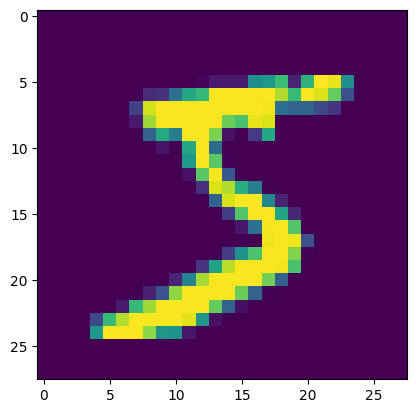

In [24]:
plt.imshow(X_train[0])

Geleneksel sinir ağlarıyla, görüntüyü olduğu gibi girdi olarak alamayız. Bu nedenle, görüntüleri her biri 1 x (28 x 28) = 1 x 784 boyutunda tek boyutlu vektörlere dönüştürmemiz gerekir.

In [25]:
# flatten images into one-dimensional vector

num_pixels = X_train.shape[1] * X_train.shape[2]     # görüntünün genişlik ve yüksekliğini çarparak tek boyutlu vektörün uzunluğunu hesaplar

X_train = X_train.reshape(X_train.shape[0], num_pixels).astype('float32')  # eğitim görüntülerini 2D formattan tek boyutlu vektöre çevirir ve veri tipini float32 yapar
X_test = X_test.reshape(X_test.shape[0], num_pixels).astype('float32')     # test görüntülerini de aynı şekilde tek boyutlu vektöre çevirir ve float32 tipine dönüştürür

Piksel değerleri 0 ile 255 arasında değişebildiğinden, vektörleri 0 ile 1 arasında olacak şekilde normalize edelim.

In [26]:
# normalize inputs from 0-255 to 0-1
X_train = X_train / 255
X_test = X_test / 255

Son olarak, modelimizi oluşturmaya başlamadan önce, sınıflandırma için hedef değişkenimizi kategorilere ayırmamız gerektiğini hatırlatalım. Bunun için Keras Utilities paketindeki to_categorical fonksiyonunu kullanacağız.

In [27]:
# one hot encode outputs
y_train = to_categorical(y_train)   # eğitim etiketlerini one-hot encoding formatına çevirir (örn. sınıf 3 → [0,0,0,1,0,...])
y_test = to_categorical(y_test)     # test etiketlerini de aynı şekilde one-hot encoding formatına çevirir

num_classes = y_test.shape[1]       # çıktı katmanındaki nöron sayısını belirler (sınıf sayısı)
print(num_classes)                  # sınıf sayısını ekrana yazdırır

10


In [28]:
## Build a Neural Network
# define classification model
def classification_model():                                 # sınıflandırma problemi için bir sinir ağı modeli oluşturan fonksiyon
    model = Sequential()                                    # katmanların sırayla eklendiği bir neural network modeli oluşturur
    
    model.add(Input(shape=(num_pixels,)))                   # giriş katmanı: tek boyutlu görüntü vektörü alır (flatten edilmiş)
    
    model.add(Dense(num_pixels, activation='relu'))         # 1. gizli katman: nöron sayısı input boyutuna eşit, ReLU aktivasyonu ile çalışır
    
    model.add(Dense(100, activation='relu'))                # 2. gizli katman: 100 nöron, ReLU aktivasyonu ile daha karmaşık ilişkileri öğrenir
    
    model.add(Dense(num_classes, activation='softmax'))    # çıkış katmanı: sınıf sayısı kadar nöron, softmax ile her sınıfa ait olasılık üretir
    
    
    # compile model
    model.compile(optimizer='adam',                          # optimizer: Adam ile ağırlıkları günceller
                  loss='categorical_crossentropy',          # loss: çok sınıflı sınıflandırma için categorical crossentropy
                  metrics=['accuracy'])                     # metric: eğitim sırasında doğruluk (accuracy) ölçülür
    
    return model                                           # oluşturulan modeli fonksiyonun çıktısı olarak döndürür

## Train and Test the Network


In [29]:
# build the model
model = classification_model()

# fit the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=2)

# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)

Epoch 1/10
1875/1875 - 68s - 37ms/step - accuracy: 0.9438 - loss: 0.1879 - val_accuracy: 0.9698 - val_loss: 0.1023
Epoch 2/10
1875/1875 - 74s - 40ms/step - accuracy: 0.9750 - loss: 0.0797 - val_accuracy: 0.9763 - val_loss: 0.0772
Epoch 3/10
1875/1875 - 67s - 36ms/step - accuracy: 0.9826 - loss: 0.0546 - val_accuracy: 0.9791 - val_loss: 0.0697
Epoch 4/10
1875/1875 - 54s - 29ms/step - accuracy: 0.9875 - loss: 0.0394 - val_accuracy: 0.9777 - val_loss: 0.0796
Epoch 5/10
1875/1875 - 53s - 29ms/step - accuracy: 0.9896 - loss: 0.0312 - val_accuracy: 0.9741 - val_loss: 0.0911
Epoch 6/10
1875/1875 - 54s - 29ms/step - accuracy: 0.9912 - loss: 0.0280 - val_accuracy: 0.9802 - val_loss: 0.0739
Epoch 7/10
1875/1875 - 54s - 29ms/step - accuracy: 0.9936 - loss: 0.0211 - val_accuracy: 0.9810 - val_loss: 0.0801
Epoch 8/10
1875/1875 - 54s - 29ms/step - accuracy: 0.9930 - loss: 0.0218 - val_accuracy: 0.9818 - val_loss: 0.0758
Epoch 9/10
1875/1875 - 54s - 29ms/step - accuracy: 0.9944 - loss: 0.0187 - val_a

Doğruluk oranını ve buna karşılık gelen hatayı yazdıralım.

In [30]:
print('Accuracy: {}% \n Error: {}'.format(scores[1], 1 - scores[1]))        

Accuracy: 0.9807999730110168% 
 Error: 0.019200026988983154


Sadece 10 epoch çalıştırmak bile 20 dakikadan fazla sürebilir. Ancak sonuçlar oluşturulurken bunların keyfini çıkarın.

Bazen, özellikle işlem kaynaklarınız sınırlıysa ve modelinizin eğitimi uzun sürebiliyorsa, modelinizi her kullanmak istediğinizde yeniden eğitmek için zamanınız olmayabilir. Bu nedenle, Keras kütüphanesi ile eğitimden sonra modelinizi kaydedebilirsiniz. Bunu yapmak için save yöntemini kullanırız.

In [31]:
model.save('classification_model.keras')

Since our model contains multidimensional arrays of data, then models are usually saved as .keras files.


When you are ready to use your model again, you use the load_model function from <strong>keras.saving</strong>.


In [32]:
pretrained_model = keras.saving.load_model('classification_model.keras')

<h3>Practice Exercise 1</h3>


6 yoğun katmandan oluşan bir sinir ağı modeli oluşturun ve doğruluğunu karşılaştırın.

In [34]:
def classification_model_6layers():
    # create model
    
    model = Sequential()
    model.add(Input(shape=(num_pixels,)))
    model.add(Dense(num_pixels, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    
    
    # compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# build the model
model_6layers = classification_model_6layers()

# fit the model
model_6layers.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=2)

# evaluate the model
scores_6layers = model_6layers.evaluate(X_test, y_test, verbose=0)

print('Accuracy_3_layers: {}% \n Accuracy_6_layers: {}'.format(scores[1], scores_6layers[1]))  

Epoch 1/10
1875/1875 - 59s - 31ms/step - accuracy: 0.9330 - loss: 0.2219 - val_accuracy: 0.9676 - val_loss: 0.1067
Epoch 2/10
1875/1875 - 56s - 30ms/step - accuracy: 0.9711 - loss: 0.0989 - val_accuracy: 0.9701 - val_loss: 0.1075
Epoch 3/10
1875/1875 - 57s - 30ms/step - accuracy: 0.9791 - loss: 0.0711 - val_accuracy: 0.9748 - val_loss: 0.0939
Epoch 4/10
1875/1875 - 56s - 30ms/step - accuracy: 0.9832 - loss: 0.0577 - val_accuracy: 0.9746 - val_loss: 0.0914
Epoch 5/10
1875/1875 - 56s - 30ms/step - accuracy: 0.9867 - loss: 0.0458 - val_accuracy: 0.9777 - val_loss: 0.0725
Epoch 6/10
1875/1875 - 56s - 30ms/step - accuracy: 0.9884 - loss: 0.0393 - val_accuracy: 0.9776 - val_loss: 0.0891
Epoch 7/10
1875/1875 - 56s - 30ms/step - accuracy: 0.9899 - loss: 0.0345 - val_accuracy: 0.9802 - val_loss: 0.0801
Epoch 8/10
1875/1875 - 57s - 30ms/step - accuracy: 0.9915 - loss: 0.0291 - val_accuracy: 0.9757 - val_loss: 0.1193
Epoch 9/10
1875/1875 - 57s - 30ms/step - accuracy: 0.9920 - loss: 0.0276 - val_a

Double-click <b>here</b> for the solution.

<!-- Your answer is below:
def classification_model_6layers():
    # create model
    
    model = Sequential()
    model.add(Input(shape=(num_pixels,)))
    model.add(Dense(num_pixels, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    
    
    # compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# build the model
model_6layers = classification_model_6layers()

# fit the model
model_6layers.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=2)

# evaluate the model
scores_6layers = model_6layers.evaluate(X_test, y_test, verbose=0)

print('Accuracy_3_layers: {}% \n Accuracy_6_layers: {}'.format(scores[1], scores_6layers[1]))   

-->


<h3>Practice Exercise 2</h3>


Şimdi, daha önce kaydedilen modeli yükleyin, 10 epoch daha eğitin ve doğruluğunu kontrol edin.

In [35]:
#load the saved model
pretrained_model = keras.saving.load_model('classification_model.keras')

print("Pre-trained model loaded successufully")

# Further train the loaded model
pretrained_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=2)

# evaluate the model
scores_20_epochs = pretrained_model.evaluate(X_test, y_test, verbose=0)
print('Accuracy_10_epochs: {}% \n Accuracy_20_epochs: {}'.format(scores[1], scores_20_epochs[1]))   

Pre-trained model loaded successufully
Epoch 1/10
1875/1875 - 55s - 29ms/step - accuracy: 0.9950 - loss: 0.0164 - val_accuracy: 0.9841 - val_loss: 0.0824
Epoch 2/10
1875/1875 - 54s - 29ms/step - accuracy: 0.9962 - loss: 0.0121 - val_accuracy: 0.9802 - val_loss: 0.1026
Epoch 3/10
1875/1875 - 54s - 29ms/step - accuracy: 0.9960 - loss: 0.0133 - val_accuracy: 0.9792 - val_loss: 0.1095
Epoch 4/10
1875/1875 - 54s - 29ms/step - accuracy: 0.9968 - loss: 0.0101 - val_accuracy: 0.9834 - val_loss: 0.0928
Epoch 5/10
1875/1875 - 54s - 29ms/step - accuracy: 0.9965 - loss: 0.0124 - val_accuracy: 0.9828 - val_loss: 0.1002
Epoch 6/10
1875/1875 - 54s - 29ms/step - accuracy: 0.9958 - loss: 0.0133 - val_accuracy: 0.9826 - val_loss: 0.1002
Epoch 7/10
1875/1875 - 54s - 29ms/step - accuracy: 0.9970 - loss: 0.0100 - val_accuracy: 0.9822 - val_loss: 0.1077
Epoch 8/10
1875/1875 - 54s - 29ms/step - accuracy: 0.9967 - loss: 0.0108 - val_accuracy: 0.9821 - val_loss: 0.1129
Epoch 9/10
1875/1875 - 54s - 29ms/step - 

Double-click <b>here</b> for the solution.

<!-- Your answer is below:

#load the saved model
pretrained_model = keras.saving.load_model('classification_model.keras')

print("Pre-trained model loaded successufully")

# Further train the loaded model
pretrained_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=2)

# evaluate the model
scores_20_epochs = pretrained_model.evaluate(X_test, y_test, verbose=0)
print('Accuracy_10_epochs: {}% \n Accuracy_20_epochs: {}'.format(scores[1], scores_20_epochs[1]))   

-->


### Thank you for completing this lab!

This notebook was created by [Alex Aklson](https://www.linkedin.com/in/aklson/). I hope you found this lab interesting and educational. Feel free to contact me if you have any questions!


<!--
## Change Log

|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2024-11-20  | 3.0  |   Aman   |  Updated the library versions to current |
| 2020-09-21  | 2.0  | Srishti  |  Migrated Lab to Markdown and added to course repo in GitLab |



<hr>

## <h3 align="center"> © IBM Corporation. All rights reserved. <h3/>


## <h3 align="center"> &#169; IBM Corporation. All rights reserved. <h3/>

